
## Data Engineering TakeHome challenge for NYC Jobs

In [1]:
import findspark
findspark.init()

In [2]:
from pyspark.sql import SparkSession, DataFrame

# Connect to Spark cluster when running in Docker (master is set via env MASTER=spark://master:7077)
spark = SparkSession.builder \
    .appName("pyspark-assesment") \
    .getOrCreate()

### Import required library and functions

In [3]:
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import StructType, StructField, StringType, IntegerType
from pyspark.sql.functions import broadcast
from pyspark.sql import DataFrame
from typing import List




### Load data

In [4]:
df_nyc = spark.read.csv("/dataset/nyc-jobs.csv", header=True)
display(df_nyc)

DataFrame[Job ID: string, Agency: string, Posting Type: string, # Of Positions: string, Business Title: string, Civil Service Title: string, Title Code No: string, Level: string, Job Category: string, Full-Time/Part-Time indicator: string, Salary Range From: string, Salary Range To: string, Salary Frequency: string, Work Location: string, Division/Work Unit: string, Job Description: string, Minimum Qual Requirements: string, Preferred Skills: string, Additional Information: string, To Apply: string, Hours/Shift: string, Work Location 1: string, Recruitment Contact: string, Residency Requirement: string, Posting Date: string, Post Until: string, Posting Updated: string, Process Date: string]

### Sample function

In [5]:
def get_salary_frequency(df: DataFrame) -> list:
    row_list = df.select('Salary Frequency').distinct().collect()
    return [row['Salary Frequency'] for row in row_list]

### Example of test function

In [6]:
mock_data = [('A', 'Annual'), ('B', 'Daily')]
expected_result = ['Annual', 'Daily']

In [7]:
def test_get_salary_frequency(mock_data: list, 
                              expected_result: list,
                              schema: list = ['id', 'Salary Frequency']):  
    mock_df = spark.createDataFrame(data=mock_data, schema=schema)
    assert get_salary_frequency(mock_df) == expected_result

# Run the test
test_get_salary_frequency(mock_data, expected_result)


# Part 1: Data Profiling



### 1.1 Row Count

In [8]:
df_nyc.count()
display(df_nyc.count())

2946

### 1.2 Schema(Everything read as CSV)

In [10]:
df_nyc.printSchema()

root
 |-- Job ID: string (nullable = true)
 |-- Agency: string (nullable = true)
 |-- Posting Type: string (nullable = true)
 |-- # Of Positions: string (nullable = true)
 |-- Business Title: string (nullable = true)
 |-- Civil Service Title: string (nullable = true)
 |-- Title Code No: string (nullable = true)
 |-- Level: string (nullable = true)
 |-- Job Category: string (nullable = true)
 |-- Full-Time/Part-Time indicator: string (nullable = true)
 |-- Salary Range From: string (nullable = true)
 |-- Salary Range To: string (nullable = true)
 |-- Salary Frequency: string (nullable = true)
 |-- Work Location: string (nullable = true)
 |-- Division/Work Unit: string (nullable = true)
 |-- Job Description: string (nullable = true)
 |-- Minimum Qual Requirements: string (nullable = true)
 |-- Preferred Skills: string (nullable = true)
 |-- Additional Information: string (nullable = true)
 |-- To Apply: string (nullable = true)
 |-- Hours/Shift: string (nullable = true)
 |-- Work Locatio

### Null & Empty String 

In [11]:
df_nyc.select([
    F.count(F.when(F.col(c).isNull() | (F.trim(F.col(c)) == ""), 1)).alias(c)
    for c in df_nyc.columns
]).show(vertical=True)

-RECORD 0-----------------------------
 Job ID                        | 0    
 Agency                        | 0    
 Posting Type                  | 0    
 # Of Positions                | 0    
 Business Title                | 0    
 Civil Service Title           | 0    
 Title Code No                 | 0    
 Level                         | 0    
 Job Category                  | 2    
 Full-Time/Part-Time indicator | 195  
 Salary Range From             | 0    
 Salary Range To               | 0    
 Salary Frequency              | 0    
 Work Location                 | 0    
 Division/Work Unit            | 0    
 Job Description               | 0    
 Minimum Qual Requirements     | 18   
 Preferred Skills              | 259  
 Additional Information        | 563  
 To Apply                      | 180  
 Hours/Shift                   | 1062 
 Work Location 1               | 1138 
 Recruitment Contact           | 1763 
 Residency Requirement         | 678  
 Posting Date            

### Key Business Columns

In [113]:
df_nyc.select(
    "Job ID", "Agency", "Job Category",
    "Salary Range From", "Salary Range To",
    "Salary Frequency", "Posting Date"
).show(2, truncate=False)

+------+----------------------------+------------+-----------------+---------------+----------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|Job ID|Agency                      |Job Category|Salary Range From|Salary Range To|Salary Frequency|Posting Date                                                                                                                                                                                                                                                                                                                                                                                                

### Explicit Type Casting | Data Correctness | Handled unwanted symbols from columns data | Column renamed

In [14]:
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, IntegerType


def build_analytics_df(raw_df):
    """
    Cast salary and date columns for KPI analysis.
    Normalize salary to annual for comparison.
    Optimized for Spark execution.
    """

    # Common expressions
    salary_from_expr = F.regexp_replace(F.col("Salary Range From"), "[,$]", "").cast(DoubleType())
    salary_to_expr   = F.regexp_replace(F.col("Salary Range To"), "[,$]", "").cast(DoubleType())
    freq_lower       = F.lower(F.col("Salary Frequency"))

    annual_factor = (
        F.when(freq_lower.contains("hour"), F.lit(2080))
         .when(freq_lower.contains("day"), F.lit(260))
         .otherwise(F.lit(1))
    )

    return (
        raw_df
        .select(
            "*",
            salary_from_expr.alias("salary_from"),
            salary_to_expr.alias("salary_to"),
            F.to_date("Posting Date", "yyyy-MM-dd").alias("posting_date"),
            F.regexp_replace("# Of Positions", "[^0-9]", "").cast(IntegerType()).alias("num_positions"),
            annual_factor.alias("annual_factor")
        )
        .withColumn("salary_annual_from", F.col("salary_from") * F.col("annual_factor"))
        .withColumn("salary_annual_to", F.col("salary_to") * F.col("annual_factor"))
        .withColumn(
            "salary_mid_annual",
            (F.col("salary_annual_from") + F.col("salary_annual_to")) / 2
        )
        .drop("annual_factor")
    )


# -----------------------------
# Build analytics DF
# -----------------------------
df_analytics = build_analytics_df(df_nyc)

# Filter rows with valid salary midpoint (salary KPIs only)
df_sal = df_analytics.filter(
    (F.col("salary_mid_annual").isNotNull()) &
    (F.col("salary_mid_annual") > 0)
)

print(
    "Rows with valid salary for salary-based KPIs:",
    df_sal.count()
)

Rows with valid salary for salary-based KPIs: 2946


### KPI's Calculations


### KPI 1: Number of job postings per category (Top 10)
#### Objective: Identify which job categories have the highest number of open positions.


In [15]:
df_cat = df_nyc.withColumn(
    "Job Category",
    F.when(
        F.col("Job Category").isNull() | (F.trim(F.col("Job Category")) == ""),
        F.lit("Unspecified")
    ).otherwise(F.col("Job Category"))
)
kpi1_agg= (
    df_cat.groupBy("Job Category")
          .count()
          .withColumn(
              "rank",
              F.dense_rank().over(Window.orderBy(F.desc("count")))
          )
          .filter(F.col("rank") <= 10)
          .orderBy(F.desc("count"))
          .drop("rank")
)

kpi1_agg.show(truncate=False)

+-----------------------------------------+-----+
|Job Category                             |count|
+-----------------------------------------+-----+
|Engineering, Architecture, & Planning    |504  |
|Technology, Data & Innovation            |313  |
|Legal Affairs                            |226  |
|Public Safety, Inspections, & Enforcement|182  |
|Building Operations & Maintenance        |181  |
|Finance, Accounting, & Procurement       |169  |
|Administration & Human Resources         |134  |
|Constituent Services & Community Programs|129  |
|Health                                   |125  |
|Policy, Research & Analysis              |124  |
+-----------------------------------------+-----+



In [16]:
def plot_horizontal_bar(df, category_col, value_col, title):
    pdf = df.toPandas().sort_values(value_col)
    plt.figure(figsize=(10, 5))
    plt.barh(pdf[category_col], pdf[value_col])
    plt.xlabel("Number of job postings")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [ ]:
kpi1_agg.columns

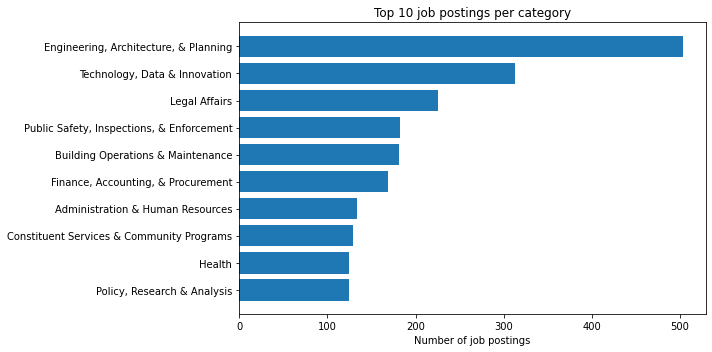

In [17]:
plot_horizontal_bar(
    kpi1_agg,
    "Job Category",
    "count",
    "Top 10 job postings per category"
)

### KPI 2: Salary distribution per job category

In [21]:
# Window to rank categories by posting count
cat_window = Window.orderBy(F.desc("count"))

kpi2 = (
    df_sal
    .groupBy("Job Category")
    .agg(
        F.count("*").alias("count"),
        F.avg("salary_mid_annual").alias("avg_salary"),
        F.min("salary_mid_annual").alias("min_salary"),
        F.max("salary_mid_annual").alias("max_salary")
    )
    .withColumn("rank", F.dense_rank().over(cat_window))
    .filter(F.col("rank") <= 10)
    .orderBy(F.desc("avg_salary"))
    .drop("rank")
)

kpi2.show(truncate=False)

+-----------------------------------------+-----+-----------------+------------------+----------+
|Job Category                             |count|avg_salary       |min_salary        |max_salary|
+-----------------------------------------+-----+-----------------+------------------+----------+
|Technology, Data & Innovation            |313  |90939.57863258786|32957.600000000006|169011.0  |
|Engineering, Architecture, & Planning    |504  |85129.01674603175|363.92            |151795.0  |
|Legal Affairs                            |226  |84739.9537876106 |37398.0           |191913.0  |
|Health                                   |125  |77541.46467199999|33166.0           |170133.84 |
|Finance, Accounting, & Procurement       |169  |74945.58118343195|21539.5           |167500.0  |
|Policy, Research & Analysis              |124  |67388.16354838709|175.1             |162051.0  |
|Constituent Services & Community Programs|129  |67209.49485271318|31371.5           |135000.0  |
|Public Safety, Insp

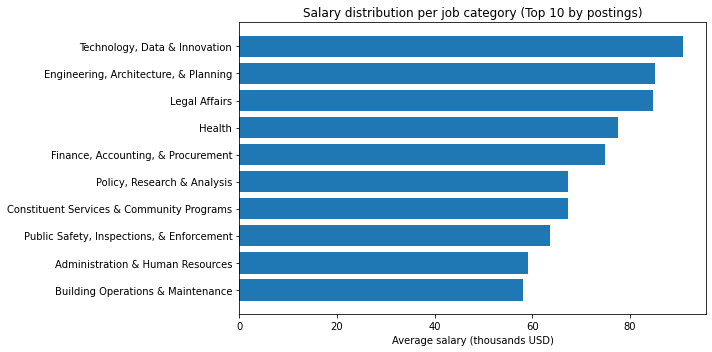

In [22]:
kpi2_pd = kpi2.toPandas().sort_values("avg_salary")

plt.figure(figsize=(10, 5))
plt.barh(kpi2_pd["Job Category"], kpi2_pd["avg_salary"] / 1000)
plt.xlabel("Average salary (thousands USD)")
plt.title("Salary distribution per job category (Top 10 by postings)")
plt.tight_layout()
plt.show()

### KPI 3: Correlation between higher degree and salary

We derive a "highest degree" level from the Minimum Qual Requirements text (e.g. baccalaureate, master's, PhD) and compare average salary.

### Create a Degree Lookup Table (small dimension)

In [23]:
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, IntegerType

degree_lookup_data = [
    ("PhD",        r"ph\.?d|doctorate",                    5),
    ("Master",     r"master'?s|m\.?b\.?a|graduate degree", 4),
    ("Bachelor",   r"baccalaureate|bachelor|four[- ]year college", 3),
    ("Associate",  r"associate|60 semester credits",       2),
    ("High school",r"high school|ged|equivalent",          1)
]

degree_schema = StructType([
    StructField("degree_level", StringType()),
    StructField("pattern", StringType()),
    StructField("degree_rank", IntegerType())
])

degree_lookup_df = spark.createDataFrame(degree_lookup_data, degree_schema)

In [25]:
df_req = df_sal.withColumn(
    "req", F.lower(F.coalesce(F.col("Minimum Qual Requirements"), F.lit("")))
)

# Regex join using SQL expression
df_joined = df_req.join(
    broadcast(degree_lookup_df),
    F.expr("req RLIKE pattern"),
    "left"
)

# Resolve multiple matches (highest degree wins)
w = Window.partitionBy("Job ID")

df_degree_final = (
    df_joined
    .withColumn("degree_rank_filled", F.coalesce("degree_rank", F.lit(0)))
    .withColumn("max_rank", F.max("degree_rank_filled").over(w))
    .filter(F.col("degree_rank_filled") == F.col("max_rank"))
    .dropDuplicates(["Job ID"])
    .withColumn(
        "degree_level",
        F.when(F.col("degree_rank_filled") == 0, "Unspecified")
         .otherwise(F.col("degree_level"))
    )
)
kpi3 = (
    df_degree_final
    .groupBy("degree_level", "degree_rank_filled")
    .agg(
        F.avg("salary_mid_annual").alias("avg_salary"),
        F.count("*").alias("count")
    )
    .orderBy("degree_rank_filled")
)

kpi3.show(truncate=False)




+------------+------------------+-----------------+-----+
|degree_level|degree_rank_filled|avg_salary       |count|
+------------+------------------+-----------------+-----+
|Unspecified |0                 |76167.53705439738|307  |
|High school |1                 |54307.75035416667|192  |
|Associate   |2                 |50526.94888888889|18   |
|Bachelor    |3                 |76460.03275779377|834  |
|Master      |4                 |89669.33192537312|268  |
|PhD         |5                 |86088.38095238095|42   |
+------------+------------------+-----------------+-----+



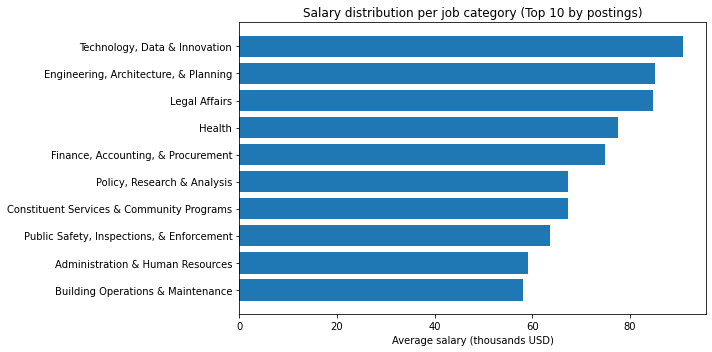

In [26]:
kpi2_pd = kpi2.toPandas().sort_values("avg_salary")

plt.figure(figsize=(10, 5))
plt.barh(kpi2_pd["Job Category"], kpi2_pd["avg_salary"] / 1000)
plt.xlabel("Average salary (thousands USD)")
plt.title("Salary distribution per job category (Top 10 by postings)")
plt.tight_layout()
plt.show()

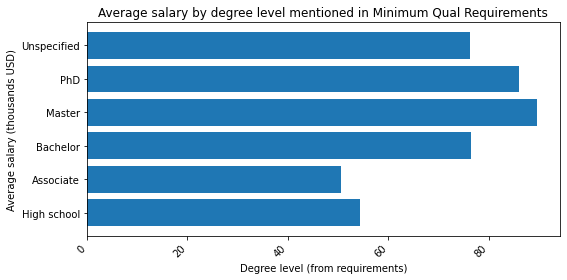

Conclusion: postings requiring higher degrees tend to show higher average salary in this dataset.


In [27]:
order_degree = ["High school", "Associate", "Bachelor", "Master", "PhD", "Unspecified"]
kpi3_pd = kpi3.toPandas()
kpi3_pd["degree_level"] = kpi3_pd["degree_level"].astype("category").cat.set_categories(order_degree)
kpi3_pd = kpi3_pd.sort_values("degree_level")
plt.figure(figsize=(8, 4))
plt.barh(kpi3_pd["degree_level"].astype(str), kpi3_pd["avg_salary"] / 1000)
plt.xlabel("Degree level (from requirements)")
plt.ylabel("Average salary (thousands USD)")
plt.title("Average salary by degree level mentioned in Minimum Qual Requirements")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
print("Conclusion: postings requiring higher degrees tend to show higher average salary in this dataset.")

### KPI 4: Job posting with highest salary per agency

In [28]:
w = Window.partitionBy("Agency").orderBy(
    F.desc("salary_mid_annual"),
    F.desc("salary_annual_to")   # deterministic tie-breaker
)

kpi4 = (
    df_sal
    .select(
        "Agency",
        "Business Title",
        "salary_mid_annual",
        "salary_annual_from",
        "salary_annual_to"
    )
    .withColumn("rn", F.row_number().over(w))
    .filter(F.col("rn") == 1)
    .drop("rn")
    .orderBy(F.desc("salary_mid_annual"))
    .limit(15)
)

kpi4.show(truncate=False)

+------------------------------+----------------------------------------------------+------------------+------------------+----------------+
|Agency                        |Business Title                                      |salary_mid_annual |salary_annual_from|salary_annual_to|
+------------------------------+----------------------------------------------------+------------------+------------------+----------------+
|DEPT OF ENVIRONMENT PROTECTION|Deputy Commissioner, Bureau of Customer Services    |218587.0          |218587.0          |218587.0        |
|POLICE DEPARTMENT             |Deputy Commissioner, Public Information, M-VII      |217201.0          |200000.0          |234402.0        |
|DISTRICT ATTORNEY KINGS COUNTY|Co-Chief Information Officer                        |191913.0          |175000.0          |208826.0        |
|NYC HOUSING AUTHORITY         |Vice-President for Support Services                 |180000.0          |175000.0          |185000.0        |
|NYC EMPLOYEE

### KPI 5: Average salary per agency for job postings in the last 2 years

+------------------------------+-----------------+-------------+
|Agency                        |avg_salary       |posting_count|
+------------------------------+-----------------+-------------+
|CONFLICTS OF INTEREST BOARD   |135000.0         |2            |
|BUSINESS INTEGRITY COMMISSION |95000.0          |2            |
|FINANCIAL INFO SVCS AGENCY    |93994.5          |20           |
|DEPT OF INFO TECH & TELECOMM  |87984.87         |50           |
|MAYORS OFFICE OF CONTRACT SVCS|87357.14285714286|28           |
|CONSUMER AFFAIRS              |87110.28571428571|7            |
|LAW DEPARTMENT                |86495.73525      |64           |
|OFFICE OF THE COMPTROLLER     |85235.71428571429|42           |
|HOUSING PRESERVATION & DVLPMNT|84882.17857142857|28           |
|DEPARTMENT OF PROBATION       |84487.21111111112|9            |
|PRESIDENT BOROUGH OF MANHATTAN|82500.0          |4            |
|HUMAN RIGHTS COMMISSION       |82444.9485       |16           |
|DEPT OF YOUTH & COMM DEV

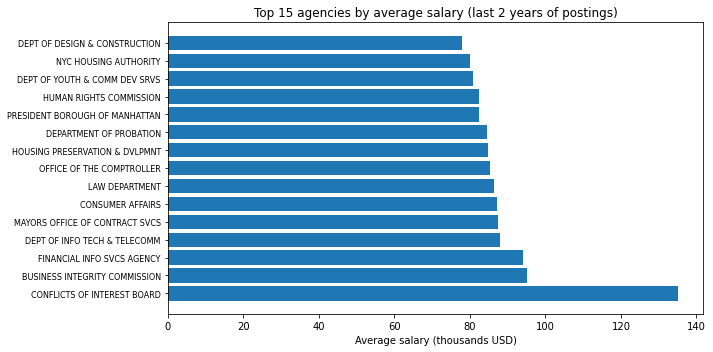

In [114]:
from pyspark.sql.window import Window

w = Window.rowsBetween(Window.unboundedPreceding, Window.unboundedFollowing)

df_last2 = (
    df_sal
    .withColumn("max_date", F.max("posting_date").over(w))
    .filter(
        F.col("posting_date").isNotNull() &
        (F.col("posting_date") >= F.add_months(F.col("max_date"), -24))
    )
)

kpi5 = (
    df_last2
    .groupBy("Agency")
    .agg(
        F.avg("salary_mid_annual").alias("avg_salary"),
        F.count("*").alias("posting_count")
    )
    .orderBy(F.desc("avg_salary"))
    .limit(15)
)

kpi5.show(truncate=False)
kpi5_pd = kpi5.toPandas()
plt.figure(figsize=(10, 5))
plt.barh(range(len(kpi5_pd)), kpi5_pd["avg_salary"] / 1000)
plt.yticks(range(len(kpi5_pd)), kpi5_pd["Agency"], fontsize=8)
plt.xlabel("Average salary (thousands USD)")
plt.title("Top 15 agencies by average salary (last 2 years of postings)")
plt.tight_layout()
plt.show()

### KPI 6: Highest-paid skills (in this dataset)

We parse Preferred Skills (and/or Job Description) for skill-like phrases and average salary per skill. Dataset is NYC jobs; we interpret "US market" as skills with highest pay in this NYC job market.

+---------------------------------------------------------+------------------+-----+
|skill                                                    |avg_salary        |count|
+---------------------------------------------------------+------------------+-----+
|commercial                                               |155213.66666666666|6    |
|public utility                                           |146779.9          |5    |
|mongodb                                                  |133971.0          |6    |
|track and staff multiple contracts for engineering design|126936.5          |5    |
|construction and construction management                 |126936.5          |5    |
|capacity to organize and analyze data                    |126936.5          |5    |
|planning                                                 |124959.1          |5    |
|procurement                                              |121998.33333333333|6    |
|presentation                                             |120875

/usr/local/lib/python3.7/dist-packages/matplotlib/backends/backend_agg.py:214: RuntimeWarning: Glyph 9 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.7/dist-packages/matplotlib/backends/backend_agg.py:183: RuntimeWarning: Glyph 9 missing from current font.
  font.set_text(s, 0, flags=flags)


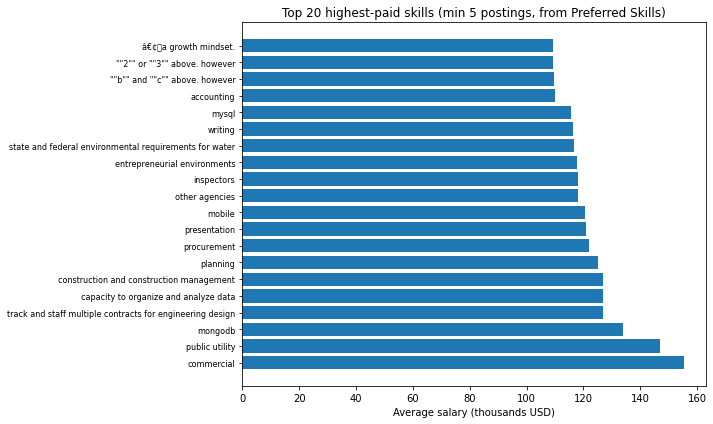

In [32]:
from pyspark.sql import functions as F

# Normalize & explode skills in one pass
skills_flat = (
    df_sal
    .select(
        "salary_mid_annual",
        F.explode(
            F.split(
                F.regexp_replace(
                    F.lower(F.coalesce(F.col("Preferred Skills"), F.lit(""))),
                    r"[,;•·\n/|()]",
                    ","
                ),
                ","
            )
        ).alias("skill")
    )
    .withColumn("skill", F.trim(F.col("skill")))
    .filter(
        (F.length("skill") >= 4) &
        (F.length("skill") <= 80)
    )
)

# Aggregate salary per skill
kpi6 = (
    skills_flat
    .groupBy("skill")
    .agg(
        F.avg("salary_mid_annual").alias("avg_salary"),
        F.count("*").alias("count")
    )
    .filter(F.col("count") >= 5)
    .orderBy(F.desc("avg_salary"))
    .limit(20)
)

kpi6.show(truncate=False)
kpi6_pd = kpi6.toPandas()
plt.figure(figsize=(10, 6))
plt.barh(range(len(kpi6_pd)), kpi6_pd["avg_salary"] / 1000)
plt.yticks(range(len(kpi6_pd)), kpi6_pd["skill"], fontsize=8)
plt.xlabel("Average salary (thousands USD)")
plt.title("Top 20 highest-paid skills (min 5 postings, from Preferred Skills)")
plt.tight_layout()
plt.show()

---
# Part 2: Data Processing

- Cleaning and column pre-processing
- At least 3 feature engineering techniques
- Feature removal based on exploration
- Store processed data to target file

### Cleaning & pre-processing functions

#### String Cleaning 

In [115]:
def clean_string_columns(df: DataFrame, cols: List[str]) -> DataFrame:
    for c in cols:
        if c in df.columns:
            df = df.withColumn(
                c,
                F.when(F.trim(F.col(c)) == "", F.lit(None))
                 .otherwise(F.trim(F.col(c)))
            )
    return df

#### Salary Casting

In [34]:
def cast_currency_columns(df: DataFrame, cols: List[str]) -> DataFrame:
    for c in cols:
        if c in df.columns:
            df = df.withColumn(
                c,
                F.regexp_replace(F.col(c), r"[^\d.]", "").cast(DoubleType())
            )
    return df

#### Date Casting

In [35]:
def cast_date_columns(df: DataFrame, cols: List[str], fmt: str = "yyyy-MM-dd") -> DataFrame:
    for c in cols:
        if c in df.columns:
            df = df.withColumn(c, F.to_date(F.col(c), fmt))
    return df

#### Numeric Casting

In [36]:
def cast_numeric_optional(df: DataFrame, col_name: str) -> DataFrame:
    if col_name not in df.columns:
        return df

    return df.withColumn(
        col_name,
        F.when(
            F.col(col_name).rlike(r"\d+"),
            F.regexp_extract(F.col(col_name), r"(\d+)", 1).cast(IntegerType())
        ).otherwise(None)
    )

#### Feature engineering (at least 3)

#### 1 - salary_midpoint_annual

In [37]:
from pyspark.sql import DataFrame
from pyspark.sql import functions as F
from pyspark.sql.window import Window

def add_salary_midpoint_annual(df):
    mid_expr = (F.col("Salary Range From") + F.col("Salary Range To")) / 2

    annual_expr = (
        F.when(F.lower(F.col("Salary Frequency")).contains("hour"), mid_expr * 2080)
         .when(F.lower(F.col("Salary Frequency")).contains("day"), mid_expr * 260)
         .otherwise(mid_expr)
    )

    return df.withColumn("salary_mid_annual", annual_expr)

#### 2- Degree Level Extraction

In [38]:
def add_degree_level(df):
    req = F.lower(F.coalesce(F.col("Minimum Qual Requirements"), F.lit("")))

    return df.withColumn(
        "degree_level",
        F.when(req.rlike(r"ph\.?d|doctorate"), "PhD")
         .when(req.rlike(r"master'?s|m\.?b\.?a|graduate degree"), "Master")
         .when(req.rlike(r"baccalaureate|bachelor|four.?year college"), "Bachelor")
         .when(req.rlike(r"associate|60 semester credits"), "Associate")
         .when(req.rlike(r"high school|ged|equivalent"), "High school")
         .otherwise("Unspecified")
    )

#### 3- Clean Number of Positions

In [39]:
from pyspark.sql.types import IntegerType

def add_num_positions_clean(df):
    return df.withColumn(
        "num_positions",
        F.when(
            F.col("# Of Positions").rlike(r"\d+"),
            F.regexp_extract(F.col("# Of Positions"), r"(\d+)", 1).cast(IntegerType())
        ).otherwise(None)
    )

#### Column Sanitization

In [47]:
def sanitize_columns(df: DataFrame) -> DataFrame:
    for c in df.columns:
        new_c = (
            c.replace(" ", "_")
             .replace("/", "_")
             .replace("#", "num_")
             .replace(";", "_")
             .replace(",", "_")
             .replace("{", "_")
             .replace("}", "_")
             .replace("(", "_")
             .replace(")", "_")
             .replace("\n", "_")
             .replace("\t", "_")
             .replace("=", "_")
             .strip("_")
        )
        if new_c != c:
            df = df.withColumnRenamed(c, new_c)
    return df

####  End-to-End Processing Function

In [111]:
COLS_TO_DROP = [
    "Job Description", "Minimum Qual Requirements", "Preferred Skills",
    "Additional Information", "To Apply", "Recruitment Contact",
    "Residency Requirement", "Work Location 1", "Division/Work Unit"
]

def process_and_save(raw_df: DataFrame, output_path: str) -> DataFrame:
    # =========================
    # CLEANING (Silver Layer)
    # =========================
    string_cols = [
        "Agency", "Business Title", "Job Category",
        "Salary Frequency", "Posting Type"
    ]

    for c in string_cols:
        if c in raw_df.columns:
            raw_df = raw_df.withColumn(
                c,
                F.when(F.trim(F.col(c)) == "", None)
                 .otherwise(F.trim(F.col(c)))
            )

    # =========================
    # CASTING
    # =========================
    raw_df = (
        raw_df
        .withColumn(
            "Salary Range From",
            F.regexp_replace(F.col("Salary Range From"), r"[^\d.]", "").cast(DoubleType())
        )
        .withColumn(
            "Salary Range To",
            F.regexp_replace(F.col("Salary Range To"), r"[^\d.]", "").cast(DoubleType())
        )
        .withColumn("Posting Date", F.to_date("Posting Date", "yyyy-MM-dd"))
    )

    # Clean numeric positions
    raw_df = raw_df.withColumn(
        "num_positions",
        F.when(
            F.col("# Of Positions").rlike(r"\d+"),
            F.regexp_extract(F.col("# Of Positions"), r"(\d+)", 1).cast(IntegerType())
        ).otherwise(None)
    )

    # =========================
    # FEATURE ENGINEERING (Gold)
    # =========================
    mid_salary = (F.col("Salary Range From") + F.col("Salary Range To")) / 2

    raw_df = raw_df.withColumn(
        "salary_mid_annual",
        F.when(F.lower(F.col("Salary Frequency")).contains("hour"), mid_salary * 2080)
         .when(F.lower(F.col("Salary Frequency")).contains("day"), mid_salary * 260)
         .otherwise(mid_salary)
    )

    # Degree extraction
    req = F.lower(F.coalesce(F.col("Minimum Qual Requirements"), F.lit("")))

    raw_df = raw_df.withColumn(
        "degree_level",
        F.when(req.rlike(r"ph\.?d|doctorate"), "PhD")
         .when(req.rlike(r"master|mba|graduate"), "Master")
         .when(req.rlike(r"bachelor|baccalaureate"), "Bachelor")
         .when(req.rlike(r"associate|60 semester"), "Associate")
         .when(req.rlike(r"high school|ged"), "High school")
         .otherwise("Unspecified")
    )

    # Posting year & recency (NO collect)
    w = Window.rowsBetween(Window.unboundedPreceding, Window.unboundedFollowing)

    raw_df = (
        raw_df
        .withColumn("max_posting_date", F.max("Posting Date").over(w))
        .withColumn("posting_year", F.year("Posting Date"))
        .withColumn(
            "years_since_posting",
            F.months_between(F.col("max_posting_date"), F.col("Posting Date")) / 12
        )
        .drop("max_posting_date")
    )

    # =========================
    # FEATURE REMOVAL
    # =========================
    drop_cols = [c for c in COLS_TO_DROP if c in raw_df.columns]
    processed = raw_df.drop(*drop_cols)
    #processed.show(50,False)

    # =========================
    # SANITIZE + WRITE
    # =========================
    df_write = sanitize_columns(processed)
    
    print("sanitize_columns schema")
    print(df_write.count())
    df_write.show(3,False)
    
    df_write.write.mode("append").parquet(output_path)

    return processed

#### Pipeline Run

In [116]:
OUTPUT_PATH = "/notebook/processed_nyc_jobs/"

processed_df = process_and_save(df_nyc, OUTPUT_PATH)

processed_df.show(5,False)

print("Processed row count:", processed_df.count())


sanitize_columns schema
2946
+------+----------------------------+------------+-----------------+----------------------------------------------------+------------------------------+-------------+-----+------------------------+-----------------------------+-----------------+---------------+----------------+----------------------+--------------------------------------------------------------------------------------------+------------+-----------------------+-----------------------+------------------------------------+-------------+-----------------+------------+------------+-------------------+
|Job_ID|Agency                      |Posting_Type|num__Of_Positions|Business_Title                                      |Civil_Service_Title           |Title_Code_No|Level|Job_Category            |Full-Time_Part-Time_indicator|Salary_Range_From|Salary_Range_To|Salary_Frequency|Work_Location         |Hours_Shift                                                                                 |Postin

Processed row count: 2946


---
# Test cases

Unit tests for key functions (cleaning, feature engineering, KPI helpers).

In [117]:
from pyspark.sql import Row
from pyspark.sql import functions as F

# -----------------------------
# Test: get_salary_frequency
# -----------------------------
def test_get_salary_frequency(mock_data, expected_result):
    df = spark.createDataFrame(
        mock_data,
        schema=["id", "Salary Frequency"]
    )
    result = get_salary_frequency(df)
    assert result == expected_result


# -----------------------------
# Test: clean_string_column
# -----------------------------
def test_clean_string_columns():
    df = spark.createDataFrame(
        [("  a  ",), ("",), (None,)],
        ["x"]
    )

    result_df = clean_string_columns(df, "x")

    rows = result_df.orderBy(F.monotonically_increasing_id()).collect()

    assert rows[0]["x"] == "a"
    assert rows[1]["x"] is None
    assert rows[2]["x"] is None


# -----------------------------
# Test: add_degree_level
# -----------------------------
def test_add_degree_level():
    df = spark.createDataFrame(
        [
            (1, "A baccalaureate degree required"),
            (2, "Master's degree preferred"),
            (3, "")
        ],
        ["id", "Minimum Qual Requirements"]
    )

    result = (
        add_degree_level(df)
        .select("degree_level")
        .rdd.map(lambda r: r[0])
        .collect()
    )

    assert result == ["Bachelor", "Master", "Unspecified"]


# -----------------------------
# Test: build_analytics_df
# -----------------------------
def test_build_analytics_df():
    df = spark.createDataFrame(
        [
            ("1", "Ag", "1", "50000", "60000", "Annual", "2019-01-01")
        ],
        [
            "Job ID",
            "Agency",
            "# Of Positions",
            "Salary Range From",
            "Salary Range To",
            "Salary Frequency",
            "Posting Date"
        ]
    )

    result_df = build_analytics_df(df)

    salary_mid = (
        result_df
        .select("salary_mid_annual")
        .first()
        .salary_mid_annual
    )

    assert salary_mid == 55000.0


# -----------------------------
# Run tests manually (optional)
# -----------------------------
test_get_salary_frequency(mock_data, expected_result)
test_clean_string_columns()
test_add_degree_level()
test_build_analytics_df()

print(" All tests passed.")

 All tests passed.


In [65]:
## Notebook Ends here